# Tabular Q-Learning - Single Agent

## Transport Task in Grid World

Author: Mostafiz Rahman

Assignment: Part 1 - Tabular Q-Learning (Single Agent)

Objective: 
 Build a Q-Learning agent from scratch that learns to pick up an item from location A and deliver it to Location B in an nxn grid world.

## Problem Statement

The goal of this projects is to train a single agent using Tabular Q-Learning.

The agent must:

1. Start from a random position.
2. Find the pickup location (A).
3. Automatically pick up the item.
4. Deliver the item to the delivery location (B).
5. Learn the shortest path through training.

In [5]:
import random
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

## Environment Setup

In this section, we create the grid world environment that will be used for training the Q-Learning agent.

In [2]:

# Grid size
GRID_SIZE = 5

# Actions (8 possible moves)
ACTIONS = [
    "UP", "DOWN", "LEFT", "RIGHT",
    "UP_LEFT", "UP_RIGHT", "DOWN_LEFT", "DOWN_RIGHT"
]
TOTAL_ACTIONS = len(ACTIONS)

# Q‑learning hyperparameters
ALPHA = 0.1          # Learning rate
GAMMA = 0.95         # Discount factor
EPSILON = 1.0        # Initial exploration rate
EPSILON_DECAY = 0.995
MIN_EPSILON = 0.01

EPISODES = 20000
MAX_STEPS = 100

# Total number of possible states:
# robot (5*5) * pickup (5*5) * package flag (2)
TOTAL_STATES = GRID_SIZE * GRID_SIZE * GRID_SIZE * GRID_SIZE * 2

print("total states: ", TOTAL_STATES)


total states:  1250


## State Encoding
We map a full state (robot position, pickup position, package status) to a unique integer index for the Q‑table.

In [3]:
def state_to_index(robot_row, robot_col, pickup_row, pickup_col, has_package):
    """
    Convert environment state to a unique index.
    Index = (((robot_row * GRID_SIZE + robot_col) * GRID_SIZE + pickup_row)
             * GRID_SIZE + pickup_col) * 2 + int(has_package)
    """
    return ((((robot_row * GRID_SIZE + robot_col) * GRID_SIZE + pickup_row)
             * GRID_SIZE + pickup_col) * 2 + int(has_package))

## Q‑Table Initialisation
We initialise the Q‑table with zeros.

In [6]:
q_table = np.zeros((TOTAL_STATES, TOTAL_ACTIONS))
print("Q‑Table shape:", q_table.shape)

Q‑Table shape: (1250, 8)


## Environment Reset
This function resets the environment at the start of each episode, ensuring no collisions between robot, pickup, and delivery positions.

In [7]:
def reset_environment():
    """Generate random starting positions for robot and pickup, with fixed delivery at bottom‑right."""
    has_package = False

    robot_row = random.randint(0, GRID_SIZE - 1)
    robot_col = random.randint(0, GRID_SIZE - 1)

    pickup_row = random.randint(0, GRID_SIZE - 1)
    pickup_col = random.randint(0, GRID_SIZE - 1)

    delivery_row = GRID_SIZE - 1
    delivery_col = GRID_SIZE - 1

    # Ensure no overlap
    while robot_row == pickup_row and robot_col == pickup_col:
        pickup_row = random.randint(0, GRID_SIZE - 1)
        pickup_col = random.randint(0, GRID_SIZE - 1)

    while robot_row == delivery_row and robot_col == delivery_col:
        robot_row = random.randint(0, GRID_SIZE - 1)
        robot_col = random.randint(0, GRID_SIZE - 1)

    while pickup_row == delivery_row and pickup_col == delivery_col:
        pickup_row = random.randint(0, GRID_SIZE - 1)
        pickup_col = random.randint(0, GRID_SIZE - 1)

    return (robot_row, robot_col, pickup_row, pickup_col,
            delivery_row, delivery_col, has_package)

## Training the Agent
We run the Q‑learning algorithm for a fixed number of episodes. The reward structure is:

Step penalty: -1

Pickup reward: +10

Delivery reward: +100

After each episode, we decay the exploration rate EPSILON.

In [8]:
# Store total reward per episode for plotting
episode_rewards = []

for episode in range(EPISODES):
    # Reset environment
    (robot_row, robot_col, pickup_row, pickup_col,
     delivery_row, delivery_col, has_package) = reset_environment()

    total_reward = 0

    for step in range(MAX_STEPS):
        # Current state index
        state_idx = state_to_index(robot_row, robot_col,
                                   pickup_row, pickup_col, has_package)

        # Epsilon‑greedy action selection
        if random.random() < EPSILON:
            action = random.randint(0, TOTAL_ACTIONS - 1)
        else:
            action = np.argmax(q_table[state_idx])

        # Remember old position for boundary penalty (optional)
        prev_row, prev_col = robot_row, robot_col

        # Execute action
        if action == 0:      # UP
            robot_row -= 1
        elif action == 1:    # DOWN
            robot_row += 1
        elif action == 2:    # LEFT
            robot_col -= 1
        elif action == 3:    # RIGHT
            robot_col += 1
        elif action == 4:    # UP_LEFT
            robot_row -= 1
            robot_col -= 1
        elif action == 5:    # UP_RIGHT
            robot_row -= 1
            robot_col += 1
        elif action == 6:    # DOWN_LEFT
            robot_row += 1
            robot_col -= 1
        elif action == 7:    # DOWN_RIGHT
            robot_row += 1
            robot_col += 1

        # Keep inside grid
        robot_row = max(0, min(robot_row, GRID_SIZE - 1))
        robot_col = max(0, min(robot_col, GRID_SIZE - 1))

        # Compute reward
        reward = -1   # step penalty

        # Pickup
        if (robot_row == pickup_row and robot_col == pickup_col
                and not has_package):
            has_package = True
            reward = 10

        # Delivery
        if (robot_row == delivery_row and robot_col == delivery_col
                and has_package):
            reward = 100

        # Next state index
        next_state_idx = state_to_index(robot_row, robot_col,
                                        pickup_row, pickup_col, has_package)

        # Q‑learning update
        current_q = q_table[state_idx][action]
        max_future_q = np.max(q_table[next_state_idx])
        new_q = current_q + ALPHA * (reward + GAMMA * max_future_q - current_q)
        q_table[state_idx][action] = new_q

        total_reward += reward

        # Stop if delivery is made
        if robot_row == delivery_row and robot_col == delivery_col and has_package:
            break

    episode_rewards.append(total_reward)

    # Decay epsilon
    EPSILON = max(MIN_EPSILON, EPSILON * EPSILON_DECAY)

print("Training completed.")

Training completed.


## Visualise Training Performance
Plot the total reward obtained per episode to observe learning progress.

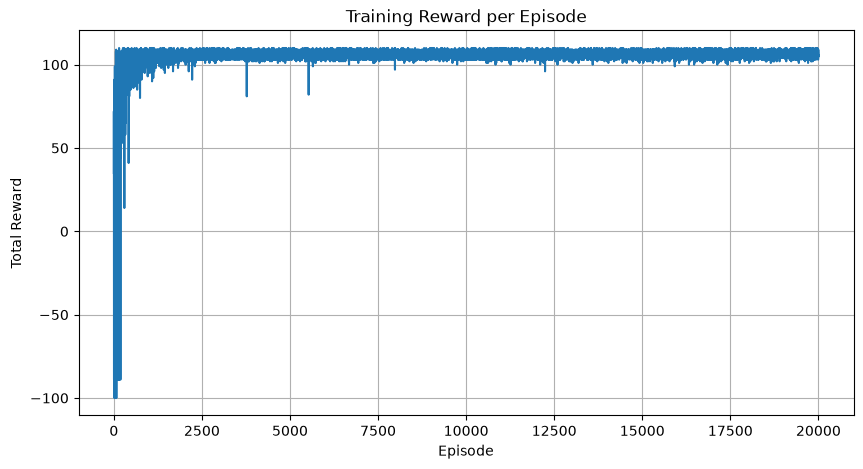

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.title("Training Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

## Testing the Trained Agent
We now run the agent with the learned policy (exploitation only) and display the grid at each step.

In [21]:
def print_grid(robot_row, robot_col, pickup_row, pickup_col,
               delivery_row, delivery_col, has_package):
    """Render the grid with emojis."""
    grid = [["🟧"] * GRID_SIZE for _ in range(GRID_SIZE)]
    grid[delivery_row][delivery_col] = "🏠"
    if not has_package:
        grid[pickup_row][pickup_col] = "📦"
    grid[robot_row][robot_col] = "🤖"
    clear_output(wait=True)
    for row in grid:
        print(" ".join(row))
        
# Reset environment for testing
(robot_row, robot_col, pickup_row, pickup_col,
 delivery_row, delivery_col, has_package) = reset_environment()

print("Testing the trained agent...\n")

for step in range(MAX_STEPS):
    print_grid(robot_row, robot_col, pickup_row, pickup_col,
               delivery_row, delivery_col, has_package)
    time.sleep(0.4)

    state_idx = state_to_index(robot_row, robot_col,
                               pickup_row, pickup_col, has_package)
    action = np.argmax(q_table[state_idx])

    # Execute action (same as training)
    if action == 0:
        robot_row -= 1
    elif action == 1:
        robot_row += 1
    elif action == 2:
        robot_col -= 1
    elif action == 3:
        robot_col += 1
    elif action == 4:
        robot_row -= 1
        robot_col -= 1
    elif action == 5:
        robot_row -= 1
        robot_col += 1
    elif action == 6:
        robot_row += 1
        robot_col -= 1
    elif action == 7:
        robot_row += 1
        robot_col += 1

    robot_row = max(0, min(robot_row, GRID_SIZE - 1))
    robot_col = max(0, min(robot_col, GRID_SIZE - 1))

    # Check pickup
    if robot_row == pickup_row and robot_col == pickup_col and not has_package:
        has_package = True
        print("\n📦 Package Picked Up!")
        time.sleep(1)

    # Check delivery
    if robot_row == delivery_row and robot_col == delivery_col and has_package:
        print_grid(robot_row, robot_col, pickup_row, pickup_col,
                   delivery_row, delivery_col, has_package)
        print(f"\n✅ Delivery accomplished in {step+1} steps!")
        print(f"Robot position   : ({robot_row}, {robot_col})")
        print(f"Pickup position  : ({pickup_row}, {pickup_col})")
        print(f"Delivery position: ({delivery_row}, {delivery_col})")
        break
else:
    print("Agent did not reach the delivery point within the step limit.")

🟧 🟧 🟧 🟧 🟧
🟧 🟧 🟧 🟧 🟧
🟧 🟧 🟧 🟧 🟧
🟧 🟧 🟧 🟧 🟧
🟧 🟧 🟧 🟧 🤖

✅ Delivery accomplished in 7 steps!
Robot position   : (4, 4)
Pickup position  : (0, 0)
Delivery position: (4, 4)


## Final Summary

In [22]:
print("\n--- Training Summary ---")
print(f"Final epsilon: {EPSILON:.4f}")
print(f"Q‑table shape: {q_table.shape}")
print("Test completed successfully.")


--- Training Summary ---
Final epsilon: 0.0100
Q‑table shape: (1250, 8)
Test completed successfully.
